# Information Presentation & Data Visualisation

## 08 Lab Exercise sheet: Networks and Trees

This lab is designed to provide hands-on practice to visualising networks and trees using Python.

## Task 1: Visualising a Social Network (Undirected Graph)
Visualise an undirected real-world Twitter network of top n = 50 influencers from SNAP datasets (https://snap.stanford.edu/data/egonets-Twitter.html).

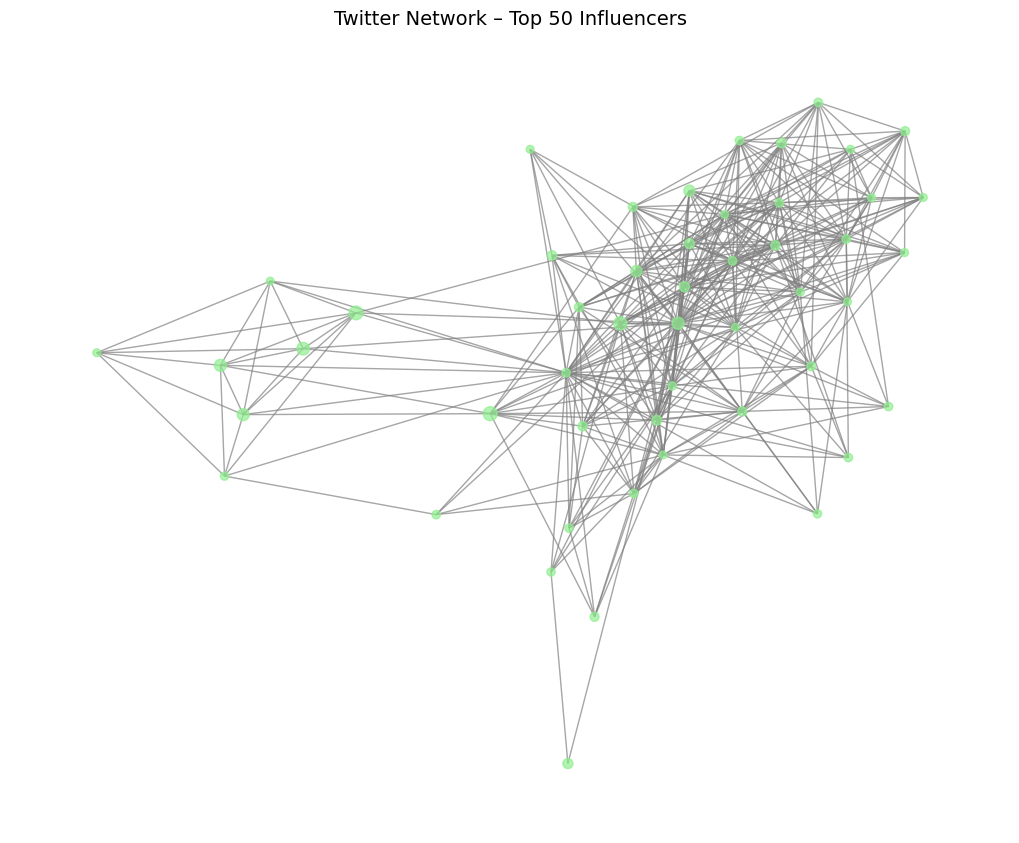

In [21]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("twitter_combined.txt", sep=" ", header=None, names=["source", "target"])

# Create undirected graph
G = nx.from_pandas_edgelist(df, source="source", target="target")

# Top 50 influencers by degree
top_50_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:50]
top_50 = [node for node, degree in top_50_nodes]

# Subgraph of top influencers
G_top50 = G.subgraph(top_50)

# Visualize the network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_top50, seed=42)

nx.draw(
    G_top50, pos,
    with_labels=False,
    node_size=[(G.degree(n) * 0.03) for n in G_top50.nodes()],
    node_color="lightgreen",
    edge_color="gray",
    alpha=0.7
)

plt.title("Twitter Network – Top 50 Influencers", fontsize=14)
plt.show()


## Task 2: Visualising a Web Navigation Graph (Directed Graph)
Create a directed network of web navigation patterns using Sankey diagrams and NetworkX using a Wikipedia's Clickstream dataset (https://meta.wikimedia.org/wiki/Research:Wikipedia_clickstream).

             prev            curr      type        n
0     other-empty  الصفحة_الرئيسة  external  1077624
1    other-search      أحمد_الشرع  external   307379
2    other-search            .xxx  external   293063
3  other-internal    شرطة_(علامة)  external   160061
4  other-internal  الصفحة_الرئيسة  external   152029
           prev           curr  type      n
79   أحمد_الشرع     حسين_الشرع  link  33339
157  أحمد_الشرع  لطيفة_الدروبي  link  23717
205  أحمد_الشرع     ماهر_الشرع  link  20314
253       سوريا     أحمد_الشرع  link  18110
619   السلفادور     نجيب_بقيلة  link  11058


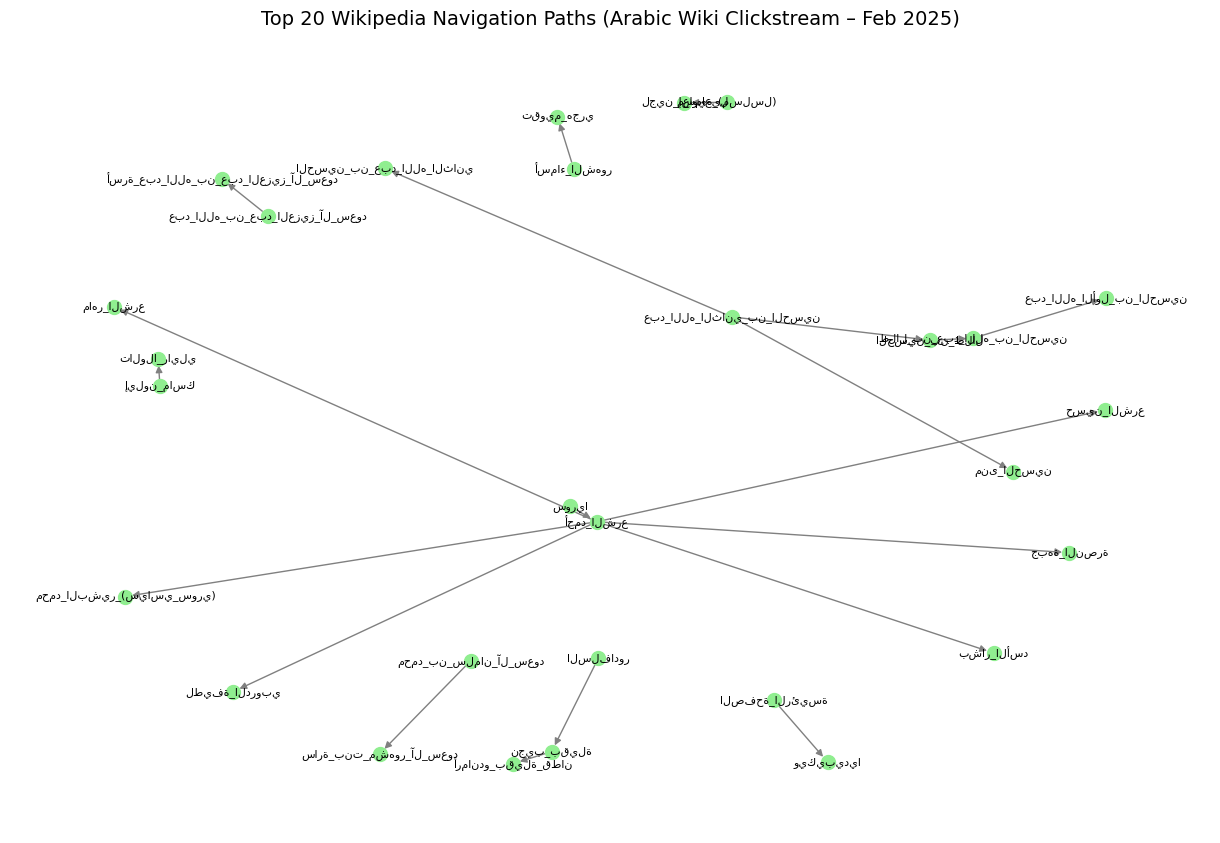

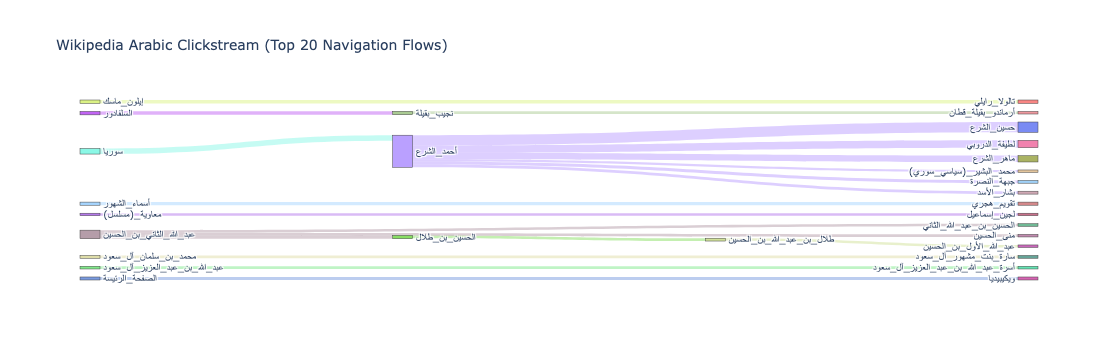

In [24]:
# Importing Required Libraries
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import random

# Loading the Dataset
df = pd.read_csv(
    "clickstream-arwiki-2025-02.tsv",
    sep="\t",
    header=None,
    names=["prev", "curr", "type", "n"]
)
print(df.head())

# Filtering Internal Wikipedia Links
df_filtered = df[df["type"] == "link"]
print(df_filtered.head())

# Creating a Directed Graph
G = nx.from_pandas_edgelist(
    df_filtered,
    source="prev",
    target="curr",
    edge_attr="n",
    create_using=nx.DiGraph()
)

# Focusing on the Top 20 Most Common Transitions
top_edges = df_filtered.nlargest(20, "n")
G_top = nx.from_pandas_edgelist(top_edges, source="prev", target="curr", edge_attr="n", create_using=nx.DiGraph())

# Visualizing the Graph (Matplotlib)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_top, seed=42)

nx.draw(
    G_top, pos,
    with_labels=True,
    node_size=100,
    node_color="lightgreen",
    edge_color="gray",
    arrows=True,
    font_size=8
)
plt.title("Top 20 Wikipedia Navigation Paths (Arabic Wiki Clickstream – Feb 2025)", fontsize=14)
plt.show()

# Preparing for the Sankey Diagram
top_links = df_filtered.nlargest(20, "n")
sources = list(top_links["prev"])
targets = list(top_links["curr"])
values = list(top_links["n"])

# Building Node and Color Mappings
all_nodes = list(set(sources + targets))
node_indices = {node: i for i, node in enumerate(all_nodes)}

colors = [
    f"rgba({random.randint(50,255)}, {random.randint(50,255)}, {random.randint(50,255)}, 0.8)"
    for _ in all_nodes
]
link_colors = [
    colors[node_indices[s]].replace("0.8", "0.4") for s in sources
]

# Creating the Sankey Diagram
link = dict(
    source=[node_indices[s] for s in sources],
    target=[node_indices[t] for t in targets],
    value=values,
    color=link_colors
)

node = dict(
    label=all_nodes,
    pad=15,
    thickness=20,
    color=colors
)
# Displaying the Interactive Sankey Chart
fig = go.Figure(data=[go.Sankey(node=node, link=link)])
fig.update_layout(
    title_text="Wikipedia Arabic Clickstream (Top 20 Navigation Flows)",
    font_size=10,
    plot_bgcolor="white"
)
fig.show()

## Task 3: Visualising a Transport Network (Weighted Graph)
Plot a weighted transportation network of an urban metro system using OpenStreetMap metro data.

In [118]:
# !pip install osmnx

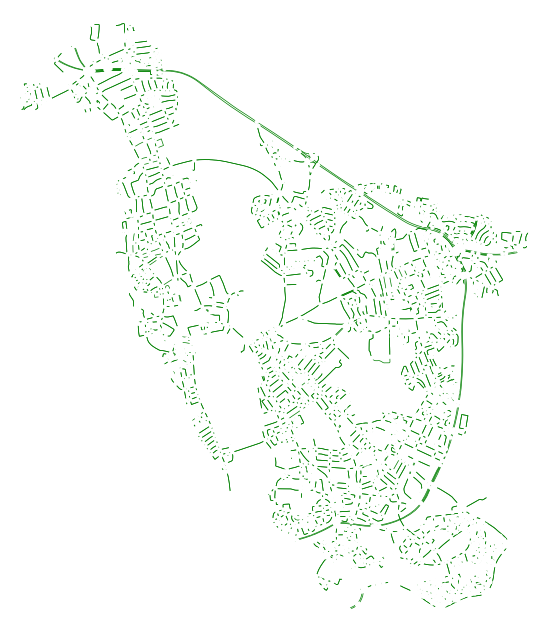

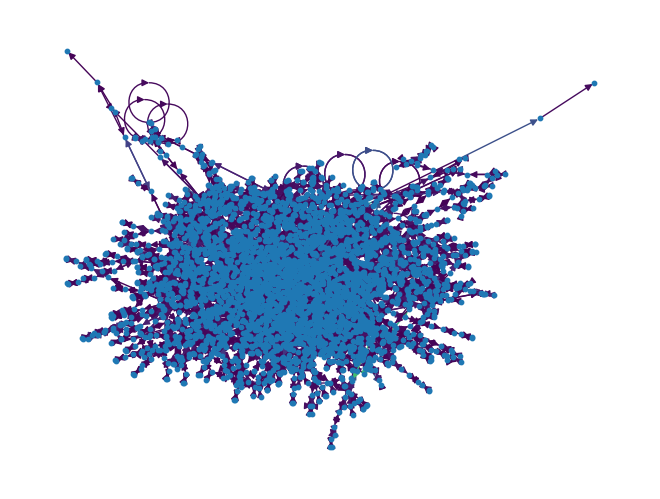

In [19]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Get the street/transportation network for London
G = ox.graph_from_place("Oxford, UK", network_type="drive")

# Plot the network
fig, ax = ox.plot_graph(G, node_size=10, edge_color='green', edge_linewidth=0.5, bgcolor='white')

# Example: visualize edges weighted by length
edge_weights = [d['length'] for u, v, d in G.edges(data=True)]
nx.draw(G, node_size=10, edge_color=edge_weights, edge_cmap=plt.cm.viridis)
plt.show()


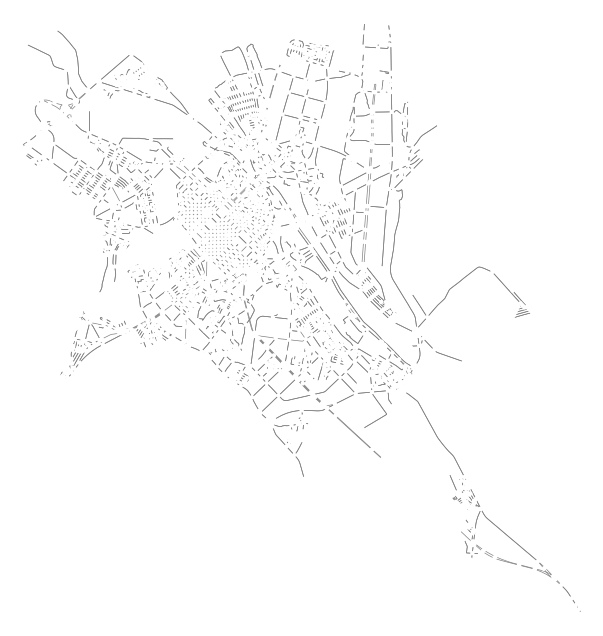

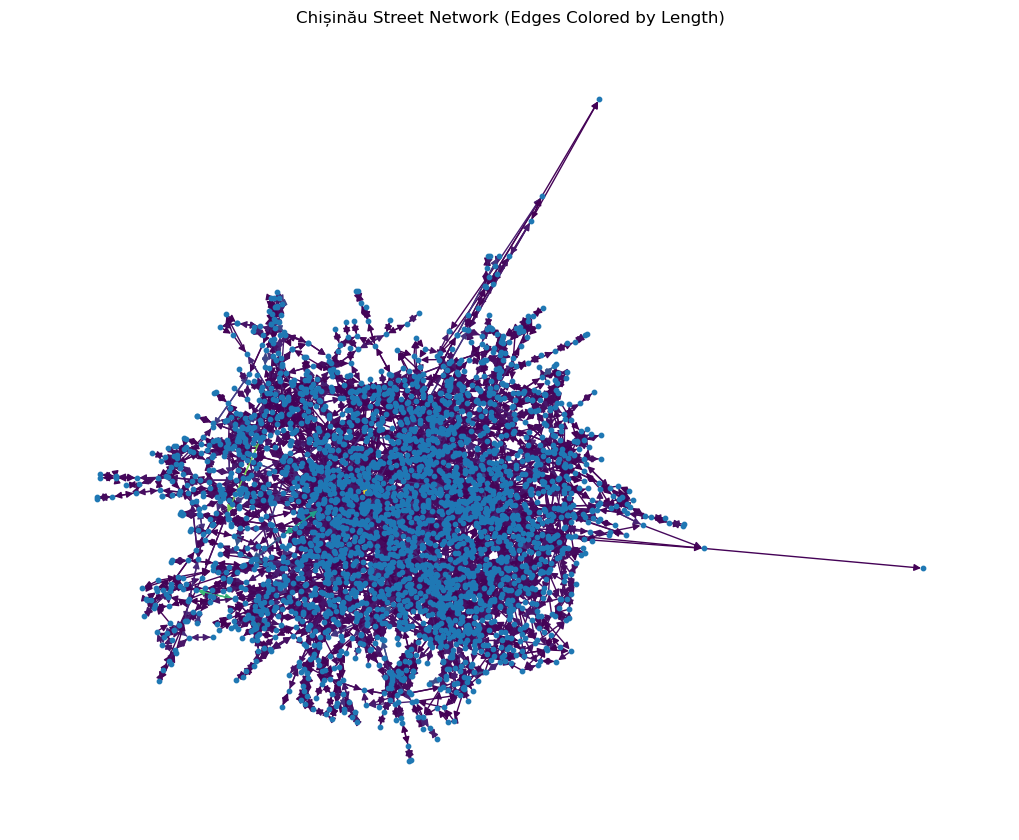

In [18]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Get the street/transportation network for Chișinău
G = ox.graph_from_place("Chișinău, Moldova", network_type="drive")

# Plot the network
fig, ax = ox.plot_graph(G, node_size=10, edge_color='gray', edge_linewidth=0.5, bgcolor='white')

# Optional: visualize edges weighted by street length
edge_weights = [d['length'] for u, v, d in G.edges(data=True)]
plt.figure(figsize=(10, 8))
nx.draw(
    G,
    node_size=10,
    edge_color=edge_weights,
    edge_cmap=plt.cm.viridis,
    width=1
)
plt.title("Chișinău Street Network (Edges Colored by Length)")
plt.show()

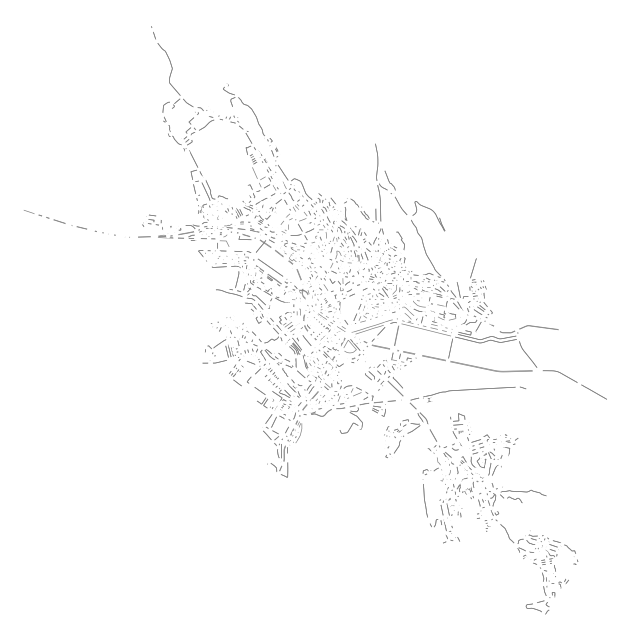

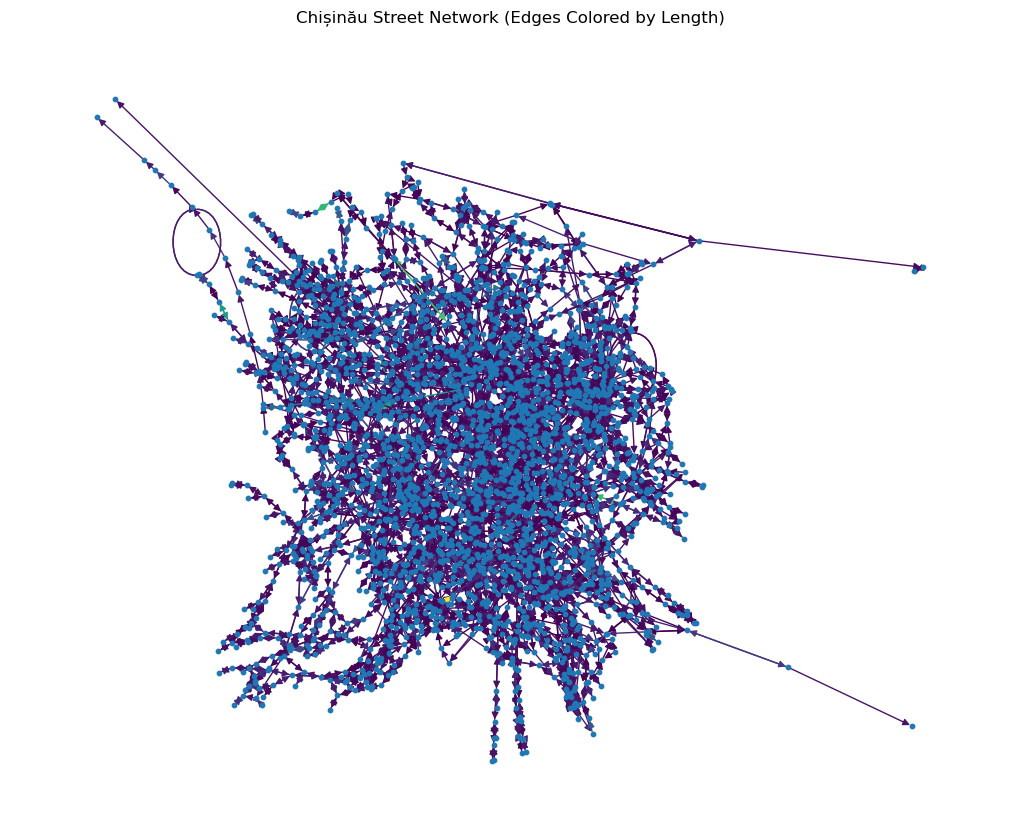

In [74]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Get the street/transportation network for Chișinău
G = ox.graph_from_place("Iași, Romania", network_type="drive")

# Plot the network
fig, ax = ox.plot_graph(G, node_size=10, edge_color='gray', edge_linewidth=0.5, bgcolor='white')

# Optional: visualize edges weighted by street length
edge_weights = [d['length'] for u, v, d in G.edges(data=True)]
plt.figure(figsize=(10, 8))
nx.draw(
    G,
    node_size=10,
    edge_color=edge_weights,
    edge_cmap=plt.cm.viridis,
    width=1
)
plt.title("Chișinău Street Network (Edges Colored by Length)")
plt.show()

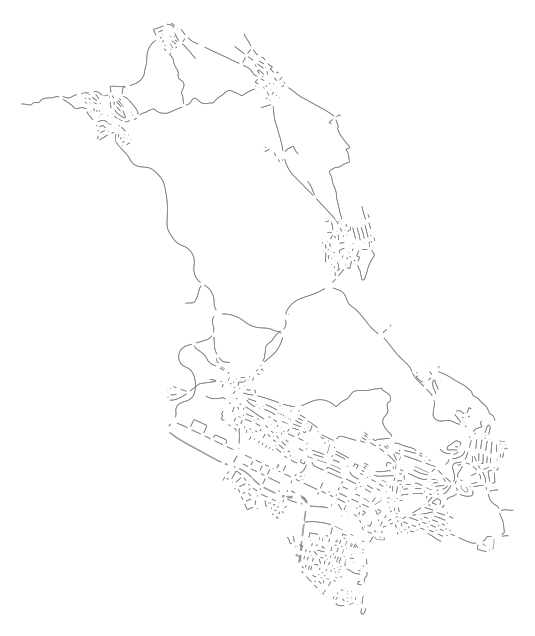

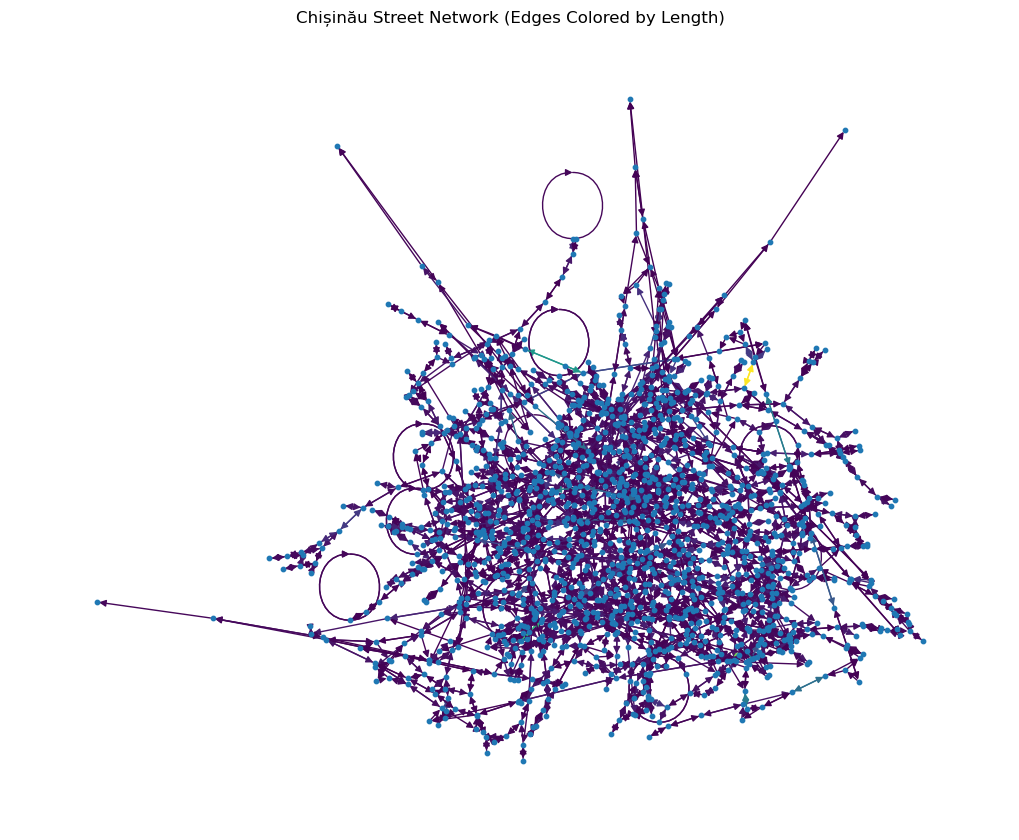

In [76]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Get the street/transportation network for Chișinău
G = ox.graph_from_place("Konstanz, Germany", network_type="drive")

# Plot the network
fig, ax = ox.plot_graph(G, node_size=10, edge_color='gray', edge_linewidth=0.5, bgcolor='white')

# Optional: visualize edges weighted by street length
edge_weights = [d['length'] for u, v, d in G.edges(data=True)]
plt.figure(figsize=(10, 8))
nx.draw(
    G,
    node_size=10,
    edge_color=edge_weights,
    edge_cmap=plt.cm.viridis,
    width=1
)
plt.title("Chișinău Street Network (Edges Colored by Length)")
plt.show()

## Task 4: Visualising a Decision Tree (Classification Task)
Train and visualize a decision tree for classifying NBA players into optimal positions.

   Unnamed: 0           Player  height  weight  \
0           0  Curly Armstrong   180.0    77.0   
1           1     Cliff Barker   188.0    83.0   
2           2    Leo Barnhorst   193.0    86.0   
3           3       Ed Bartels   196.0    88.0   
4           4      Ralph Beard   178.0    79.0   

                           collage    born   birth_city birth_state  
0               Indiana University  1918.0          NaN         NaN  
1           University of Kentucky  1921.0     Yorktown     Indiana  
2         University of Notre Dame  1924.0          NaN         NaN  
3  North Carolina State University  1925.0          NaN         NaN  
4           University of Kentucky  1927.0  Hardinsburg    Kentucky  
**************************************************
   Unnamed: 0           Player  height  weight  \
0           0  Curly Armstrong   180.0    77.0   
1           1     Cliff Barker   188.0    83.0   
2           2    Leo Barnhorst   193.0    86.0   
3           3       Ed Barte

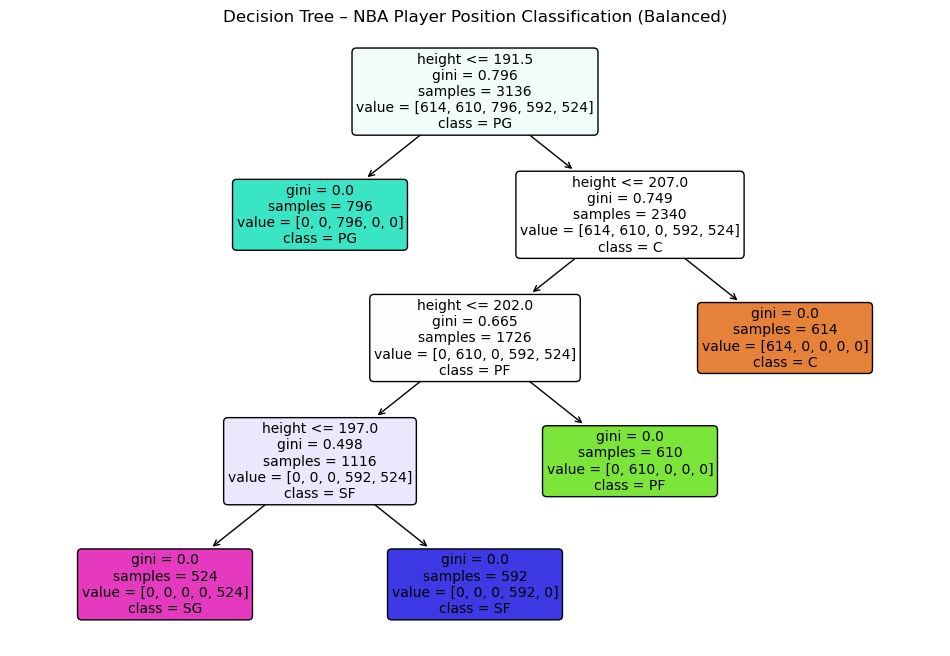

In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("nba_players.csv")
print(df.head())

print("*"*50)

df = df.dropna(subset=['height', 'weight'])
print(df.head())

print("*"*50)

# Create a balanced 'position' column
# Divide players into 5 roughly equal groups based on height
positions = ['PG', 'SG', 'SF', 'PF', 'C']
df['position'] = pd.qcut(df['height'], q=5, labels=positions)

# Step 3: Define features and target
X = df[['height', 'weight']]  # features
y = df['position']            # target

# Step 4: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 5: Train Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Step 6: Evaluate accuracy
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

print("*"*50)

# Step 7: Visualize the Decision Tree
plt.figure(figsize=(12,8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree – NBA Player Position Classification (Balanced)")
plt.show()


### Worksheets should be submitted on Canvas by the Monday after the lab at 23:59.